In [1]:
import numpy as np
import pyvista as pv
from scipy.interpolate import griddata
from pyproj import Transformer
import geopandas as gpd
import matplotlib.pyplot as plt
import VerticalPlotter as vp
from shapely.geometry import LineString

In [2]:
icon_vtk = pv.read(r"E:\HU_DATA\NCs\test_mesh.vtk")
print(icon_vtk.array_names)

['z_mc', 'PointMergeMap', 'u', 'v', 'w', 'wind', 'theta']


0    6319.236244
dtype: float64


<Axes: >

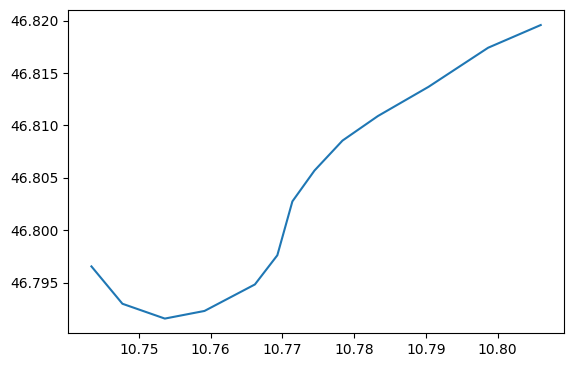

In [3]:
spline = gpd.read_file(r"C:\Users\malte\OneDrive\Arbeit_HU\Tasks\2025_T01_2D_Vertical_Plot\Spline.shp")
print(spline.to_crs("EPSG:32632").length)
spline.plot()

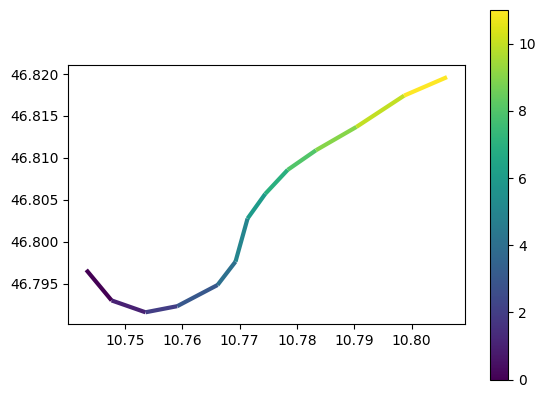

In [4]:
spline_geo = spline.geometry.iloc[0]

coords = list(spline_geo.coords)
rows = []
for i in range(len(coords)-1):
    seg = LineString([coords[i], coords[i+1]])
    rows.append({"geometry": seg, "seg_idx": i})

segs_gdf = gpd.GeoDataFrame(rows, crs=spline.crs)

ax = segs_gdf.plot(column="seg_idx", cmap="viridis", linewidth=3, legend=True)

In [5]:
VP_1 = vp.VerticalPlotter(icon_vtk, "EPSG:32632", spline, 'wind', max_height=[4000, 3800], grid_width=1, interp_method='linear')

VP_1.gpd_line_2_pv_line(100)
VP_1.generate_icon_slice()

Line length: 0    6319.236244
dtype: float64


Slicing along Line: 100%|██████████[00:01<00:00]


In [6]:
slice = VP_1.slice
spl = VP_1.pv_line

In [7]:
VP_1.slice

PolyData (0x1e2fbf3e920)
  N Cells:    9050
  N Points:   22652
  N Strips:   0
  X Bounds:   6.330e+05, 6.378e+05
  Y Bounds:   5.183e+06, 5.187e+06
  Z Bounds:   2.454e+03, 4.208e+03
  N Arrays:   8

In [11]:
om

PolyData (0x1e2fd974460)
  N Cells:    9050
  N Points:   22652
  N Strips:   0
  X Bounds:   6.330e+05, 6.378e+05
  Y Bounds:   5.183e+06, 5.187e+06
  Z Bounds:   2.454e+03, 4.208e+03
  N Arrays:   9

In [6]:
def reorder_polydata_points_inplace(mesh: pv.PolyData, new_order: np.ndarray) -> pv.PolyData:
    mesh = mesh.copy()
    n = mesh.n_points
    new_order = np.asarray(new_order, dtype=np.int64)
    if new_order.shape[0] != n:
        raise ValueError("new_order must have length equal to mesh.n_points")

    inv = np.empty(n, dtype=np.int64)
    inv[new_order] = np.arange(n, dtype=np.int64)

    old_points = mesh.points.copy()
    mesh.points = old_points[new_order]

    for name in list(mesh.point_data.keys()):
        arr = mesh.point_data[name]
        mesh.point_data[name] = arr[new_order].copy()

    def remap_indexed_array(arr):
        if arr is None or arr.size == 0:
            return arr
        arr = arr.copy()
        i = 0
        L = arr.size
        while i < L:
            k = int(arr[i])
            if k <= 0:
                i += 1
                continue
            for j in range(i+1, i+1+k):
                old_id = int(arr[j])
                arr[j] = int(inv[old_id])
            i += k + 1
        return arr

    if mesh.verts is not None and mesh.verts.size > 0:
        mesh.verts = remap_indexed_array(mesh.verts)
    if mesh.lines is not None and mesh.lines.size > 0:
        mesh.lines = remap_indexed_array(mesh.lines)
    if mesh.faces is not None and mesh.faces.size > 0:
        mesh.faces = remap_indexed_array(mesh.faces)

    return mesh


In [7]:
from scipy.spatial import cKDTree

def reorder_slice_points_by_spline(slice, spline):
    spline_pts = spline.points.copy()
    slice_pts  = slice.points.copy()

    cumdist = np.zeros(len(spline_pts), dtype=float)
    for i in range(1, len(spline_pts)):
        cumdist[i] = cumdist[i-1] + np.linalg.norm(spline_pts[i] - spline_pts[i-1])

    tree = cKDTree(spline_pts[:, :2])

    dists, nearest_idx = tree.query(slice_pts[:, :2], k=1)

    order_values = cumdist[nearest_idx]

    tie_break = dists
    sort_idx = np.lexsort((tie_break, order_values))

    ordered_mesh = reorder_polydata_points_inplace(slice, new_order=sort_idx)

    ordered_mesh.point_data['ordered_idx'] = np.arange(ordered_mesh.n_points, dtype=float)

    return ordered_mesh

om = reorder_slice_points_by_spline(slice=slice, spline=spl)

NameError: name 'spl' is not defined

In [12]:
idx = np.arange(om.n_points, dtype=float)
om.point_data["pt_idx"] = idx
om.plot(scalars="pt_idx")

Widget(value='<iframe src="http://localhost:52760/index.html?ui=P_0x1e20bd56c60_1&reconnect=auto" class="pyvis…

In [11]:
idx = np.arange(om.n_points, dtype=float)
om.point_data["pt_idx"] = idx

pv.set_jupyter_backend("trame")
p = pv.Plotter(notebook=True)
p.add_mesh(om, scalars="pt_idx", cmap="viridis", render_points_as_spheres=True)
p.show(jupyter_backend="trame")

Widget(value='<iframe src="http://localhost:52503/index.html?ui=P_0x2cd5b25ff50_0&reconnect=auto" class="pyvis…

 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpected identifier 'r'
 JS Error => error: Uncaught SyntaxError: Unexpe

In [7]:
concat_array = np.concatenate((VP_1.slice.points, VP_1.slice.get_array("wind")), axis=1)
concat_array

array([[ 6.33875783e+05,  5.18349905e+06,  2.99354786e+03,
        -4.34128680e-01,  1.72148074e+00, -1.56761035e-01],
       [ 6.33875783e+05,  5.18349905e+06,  2.98854786e+03,
        -2.70573463e+00,  2.19039470e+00,  2.79653272e-02],
       [ 6.33857410e+05,  5.18349705e+06,  2.99124006e+03,
        -2.70557767e+00,  2.18964500e+00,  2.80180553e-02],
       ...,
       [ 6.33015221e+05,  5.18404909e+06,  4.16706436e+03,
         4.16419376e+00,  2.87723341e+00,  4.65077629e-01],
       [ 6.33015221e+05,  5.18404909e+06,  4.20795410e+03,
         4.20705365e+00,  2.81263871e+00,  4.91520421e-01],
       [ 6.33015221e+05,  5.18404909e+06,  4.19624945e+03,
         4.19287459e+00,  2.83336195e+00,  4.80509729e-01]],
      shape=(22652, 6))

### Spline

In [13]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt
import numpy.ma as ma

# ---- Inputs ----
# concat_array: Nx7 array: x, y, z, u, v, w
sorted_indices = np.argsort(concat_array[:, 0])
sorted_points = VP_1.slice.points[sorted_indices]
x, y, z_vals = sorted_points[:, 0], sorted_points[:, 1], sorted_points[:, 2]

if VP_1.epsg == "EPSG:4326":
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)
    x, y = transformer.transform(x, y)

uvecs_3d = np.column_stack([VP_1.slice.get_array("u")[sorted_indices], VP_1.slice.get_array("v")[sorted_indices], VP_1.slice.get_array("w")[sorted_indices]])
N = len(x)
z_hat = np.array([0.0, 0.0, 1.0])

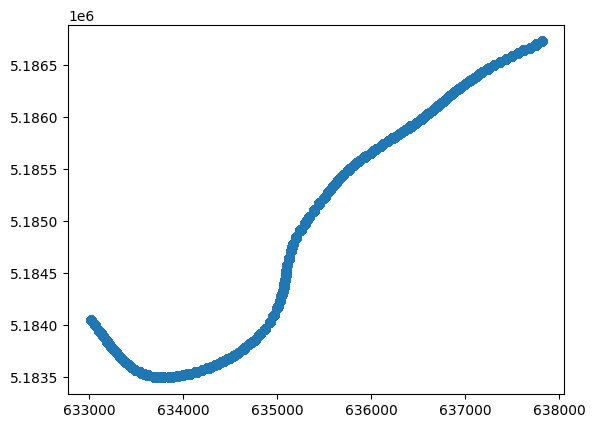

In [14]:
plt.scatter(x, y)

In [15]:
minx, maxx = np.min(x), np.max(x)
miny, maxy = np.min(y), np.max(y)

width  = maxx - minx        # bbox width (units of x)
height = maxy - miny        # bbox height (units of y)
diag   = np.sqrt(width**2 + height**2)  # diagonal length

perimeter = 2*(width + height)
area = width * height

print(f"bbox: xmin={minx}, xmax={maxx}, ymin={miny}, ymax={maxy}")
print(f"width = {width:.3f}, height = {height:.3f}")
print(f"diagonal = {diag:.3f}")
print(f"perimeter = {perimeter:.3f}, area = {area:.3f}")

# --- If you also want the length along the spline (arc length of piecewise-linear polyline) ---
dx = np.diff(x)
dy = np.diff(y)
seg_lengths = np.sqrt(dx**2 + dy**2)
arc_length = np.sum(seg_lengths)
print(f"arc length (along points) = {arc_length:.3f}")

bbox: xmin=633015.2209773042, xmax=637815.8602241615, ymin=5183494.924324566, ymax=5186726.306803772
width = 4800.639, height = 3231.382
diagonal = 5786.879
perimeter = 16064.043, area = 15512701.551
arc length (along points) = 6414.013


In [21]:
# ---- cumulative distance along slice ----
dx = np.diff(x)
dy = np.diff(y)
ds = np.sqrt(dx**2 + dy**2)
s_pts = np.concatenate([[0.0], np.cumsum(ds)])

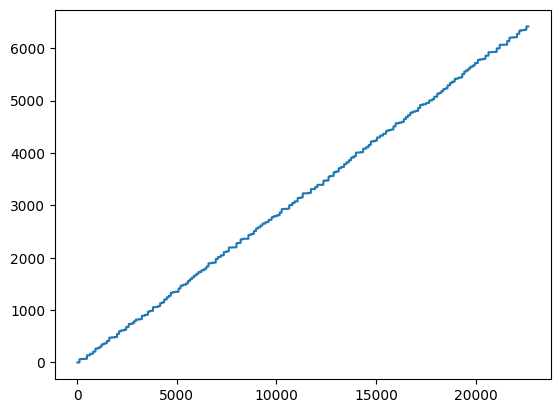

In [22]:
plt.plot(s_pts)

In [23]:
# ---- project vectors onto local vertical plane ----
u_along = np.zeros(N)
u_vert  = np.zeros(N)
prev_t = np.array([1.0,0.0,0.0])

for i in range(N-1):
    t = np.array([x[i+1]-x[i], y[i+1]-y[i], 0.0])
    norm_t = np.linalg.norm(t)
    if norm_t < 1e-12:
        t = prev_t
    else:
        t /= norm_t
    prev_t = t

    n = np.cross(z_hat, t)
    n /= np.linalg.norm(n)

    uvec = uvecs_3d[i]
    u_proj = uvec - np.dot(uvec, n) * n

    u_along[i] = np.dot(u_proj, t)
    u_vert[i]  = np.dot(u_proj, z_hat)

# last point
t = np.array([x[-1]-x[-2], y[-1]-y[-2], 0.0])
norm_t = np.linalg.norm(t)
if norm_t < 1e-12:
    t = prev_t
else:
    t /= norm_t
n = np.cross(z_hat, t)
n /= np.linalg.norm(n)
uvec = uvecs_3d[-1]
u_proj = uvec - np.dot(uvec, n) * n
u_along[-1] = np.dot(u_proj, t)
u_vert[-1] = np.dot(u_proj, z_hat)

In [19]:
import numpy as np
from scipy.signal import savgol_filter

# 1) Option A: smoothed derivative tangents (recommended)
window_length = 5
polyorder = 2
x_s = savgol_filter(x, window_length, polyorder, mode='interp')
y_s = savgol_filter(y, window_length, polyorder, mode='interp')
dx = np.gradient(x_s)
dy = np.gradient(y_s)
speeds = np.hypot(dx, dy)
speeds[speeds < 1e-12] = np.nan
tx = dx / speeds
ty = dy / speeds

# fill NaNs by nearest valid values
valid = ~np.isnan(tx)
if not valid.all():
    idx_valid = np.where(valid)[0]
    tx = np.interp(np.arange(len(tx)), idx_valid, tx[idx_valid])
    ty = np.interp(np.arange(len(ty)), idx_valid, ty[idx_valid])

t_vecs = np.vstack([tx, ty, np.zeros_like(tx)]).T   # shape (N,3)

# 2) compute lateral normals (n = cross(z_hat, t)) and normalize
z_hat = np.array([0.0, 0.0, 1.0])
n_vecs = np.cross(z_hat, t_vecs)       # shape (N,3)
n_norm = np.linalg.norm(n_vecs, axis=1)
n_norm[n_norm < 1e-12] = 1.0           # avoid division-by-zero
n_vecs = (n_vecs.T / n_norm).T

# 3) project all vectors (vectorized)
dot_un = np.sum(uvecs_3d * n_vecs, axis=1)            # (N,)
u_proj = uvecs_3d - dot_un[:, None] * n_vecs         # (N,3)

# 4) along-slice & vertical components
u_along = np.einsum('ij,ij->i', u_proj, t_vecs)     # dot product row-wise
u_vert  = u_proj[:, 2]


In [24]:
# ---- Interpolators ----
points = np.column_stack([s_pts, z_vals])
interp_along = LinearNDInterpolator(points, u_along)
interp_vert = LinearNDInterpolator(points, u_vert)

# Planar slice had roughly 200–500 points vertically, let's mimic that
Nz_desired = 500  # choose something reasonable
z_grid = np.linspace(z_vals.min(), z_vals.max(), Nz_desired)

# s_grid same as before
s_grid = np.arange(s_pts.min(), s_pts.max(), VP_1.grid_width)
Ns = len(s_grid)

grid_u_along = np.empty((Nz_desired, Ns))
grid_u_vert  = np.empty((Nz_desired, Ns))

for iz, z0 in enumerate(z_grid):
    pts_row = np.column_stack([s_grid, np.full(Ns, z0)])
    grid_u_along[iz, :] = interp_along(pts_row)
    grid_u_vert[iz, :]  = interp_vert(pts_row)


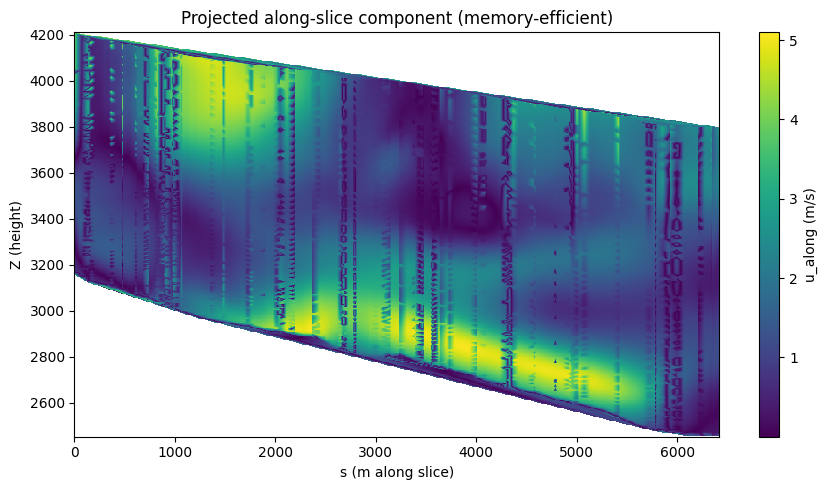

In [25]:
# grid_u_along shape = (Nz, Ns)
Zm = ma.masked_invalid(grid_u_along)

Zm = ma.masked_invalid(np.sqrt(grid_u_vert**2 + grid_u_along**2))

# Compute edges for pcolormesh
# simple: extend by half grid width at both ends
ds = s_grid[1] - s_grid[0]
dz = z_grid[1] - z_grid[0]

s_edges = np.concatenate([[s_grid[0]-ds/2], s_grid + ds/2])
z_edges = np.concatenate([[z_grid[0]-dz/2], z_grid + dz/2])

plt.figure(figsize=(9,5))
pcm = plt.pcolormesh(s_edges, z_edges, Zm, shading='auto')
plt.xlabel('s (m along slice)')
plt.ylabel('Z (height)')
plt.title('Projected along-slice component (memory-efficient)')
plt.colorbar(pcm, label='u_along (m/s)')
plt.tight_layout()
plt.show()

uvecs_3d shape: (22652, 3)


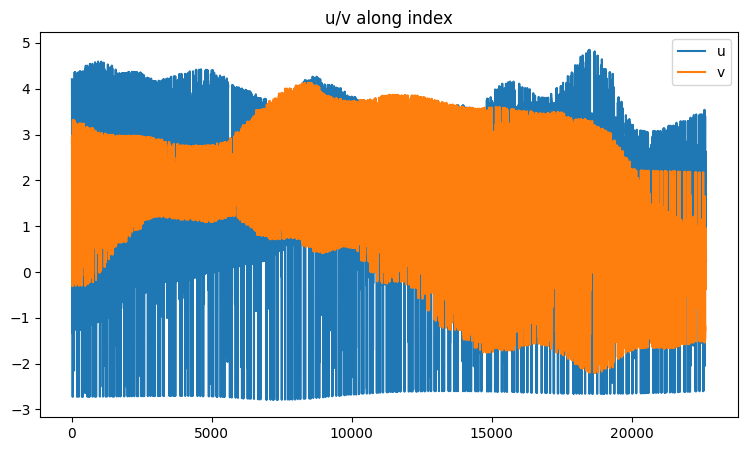

In [31]:
# compute some sanity statistics
print("uvecs_3d shape:", uvecs_3d.shape)
# quick correlation check: are u values smoothly varying along index?
plt.figure(figsize=(9,5))
plt.plot(uvecs_3d[:,0], label='u'); plt.plot(uvecs_3d[:,1], label='v'); plt.legend(); plt.title('u/v along index')
plt.show()


max repeats of same s after mapping: 408


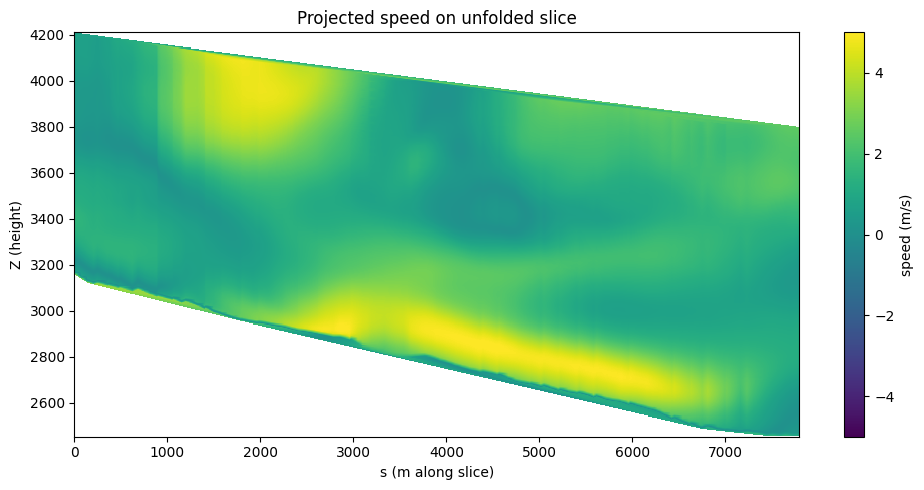

In [8]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt
import numpy.ma as ma

# ---------------------------
# Inputs (adjust names if needed)
# ---------------------------
#sorted_indices = np.argsort(concat_array[:, 0])
#sorted_points = VP_1.slice.points[sorted_indices]
#pts = sorted_points[:, 0:2]
#z_vals = sorted_points[:, 2]

pts = VP_1.slice.points[:, 0:2]
z_vals = VP_1.slice.points[:, 2]

if VP_1.epsg == "EPSG:4326":
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)
    x, y = transformer.transform(x, y)

#uvecs_3d = np.column_stack([VP_1.slice.get_array("u")[sorted_indices], VP_1.slice.get_array("v")[sorted_indices], VP_1.slice.get_array("w")[sorted_indices]])

uvecs_3d = np.column_stack([VP_1.slice.get_array("u"), VP_1.slice.get_array("v"), VP_1.slice.get_array("w")])

N = len(pts)
z_hat = np.array([0.0, 0.0, 1.0])

# If you need to reproject lon/lat -> meters, do it first (your existing transformer)

# ---------------------------
# 1) Build ordered unique ground path (remove consecutive duplicate (x,y) points)
# ---------------------------
# If points are already ordered along the slice, we keep that order and remove consecutive duplicates.
same_next = np.logical_and(np.isclose(pts[1:,0], pts[:-1,0]), np.isclose(pts[1:,1], pts[:-1,1]))
keep_mask = np.ones(N, dtype=bool)
keep_mask[1:] = ~same_next    # keep first of any run, so consecutive duplicates removed

unique_xy = pts[keep_mask]    # ordered unique ground nodes (M,2)
# Also store mapping from original index to position in unique array:
# We'll use KDTree for robust mapping (handles float tiny differences)
M = len(unique_xy)

# ---------------------------
# 2) compute s along unique path (cumulative distance)
# ---------------------------
dx = np.diff(unique_xy[:, 0])
dy = np.diff(unique_xy[:, 1])
seg = np.hypot(dx, dy)
s_unique = np.concatenate([[0.0], np.cumsum(seg)])   # length M

# If your path has very tiny segments, you can remove them or smooth:
# Optionally smooth unique_xy before derivative if you want:
# window_length must be odd and <= M. Choose based on point density.
if M >= 7:
    wl = 7 if (7 % 2 == 1) else 7+1
    x_s = savgol_filter(unique_xy[:,0], wl, polyorder=2, mode='interp')
    y_s = savgol_filter(unique_xy[:,1], wl, polyorder=2, mode='interp')
else:
    x_s = unique_xy[:,0].copy()
    y_s = unique_xy[:,1].copy()

# compute smoothed tangents on unique nodes
dx_s = np.gradient(x_s)
dy_s = np.gradient(y_s)
speed_s = np.hypot(dx_s, dy_s)
speed_s[speed_s < 1e-12] = np.nan
tx = dx_s / speed_s
ty = dy_s / speed_s
# fill NaNs by interpolation of nearest valid
valid = ~np.isnan(tx)
if not valid.all():
    idx_valid = np.where(valid)[0]
    tx = np.interp(np.arange(M), idx_valid, tx[idx_valid])
    ty = np.interp(np.arange(M), idx_valid, ty[idx_valid])
t_unique = np.vstack([tx, ty, np.zeros_like(tx)]).T   # shape (M,3)

# build lateral normals for unique nodes
n_unique = np.cross(np.array([0.,0.,1.]), t_unique)
n_norm = np.linalg.norm(n_unique, axis=1)
n_norm[n_norm < 1e-12] = 1.0
n_unique = (n_unique.T / n_norm).T

# ---------------------------
# 3) Map each original sample to nearest unique ground node (KDTree)
# ---------------------------
tree = cKDTree(unique_xy)
dists, idx_nearest = tree.query(pts, k=1)   # idx_nearest shape (N,)
# optional: check large mapping distances
if np.any(dists > 1e-3):   # threshold depends on your units (meters). tune as needed.
    print("Warning: some sample points are far from any unique node, max dist:", dists.max())

# get s for every sample and tangent/normal per sample
s_samples = s_unique[idx_nearest]           # length N
t_samples = t_unique[idx_nearest]           # shape (N,3)
n_samples = n_unique[idx_nearest]           # shape (N,3)

# ---------------------------
# 4) project velocities per-sample onto local plane and compute components
# ---------------------------
dot_un = np.einsum('ij,ij->i', uvecs_3d, n_samples)   # (N,)
u_proj = uvecs_3d - dot_un[:, None] * n_samples      # (N,3)

u_along = np.einsum('ij,ij->i', u_proj, t_samples)    # scalar along-slice (signed)
u_vert  = u_proj[:, 2]                               # vertical

# ---------------------------
# 5) optional diagnostics: check repetition of s now
# ---------------------------
sr = np.round(s_samples, 8)
_, counts = np.unique(sr, return_counts=True)
print("max repeats of same s after mapping:", counts.max())

# ---------------------------
# 6) Build interpolators and grid (memory-efficient)
# ---------------------------
points = np.column_stack([s_samples, z_vals])   # shape (N,2)
interp_along = LinearNDInterpolator(points, u_along)
interp_vert  = LinearNDInterpolator(points, u_vert)

# choose output grid resolution similar to your planar case
s_grid = np.arange(s_unique.min(), s_unique.max() + VP_1.grid_width, VP_1.grid_width)
# choose vertical resolution reasonably coarse (500 or less)
Nz_desired = 400
z_grid = np.linspace(z_vals.min(), z_vals.max(), Nz_desired)

Ns = len(s_grid); Nz = len(z_grid)
grid_u_along = np.empty((Nz, Ns))
grid_u_vert  = np.empty((Nz, Ns))

for iz, z0 in enumerate(z_grid):
    pts_row = np.column_stack([s_grid, np.full(Ns, z0)])
    grid_u_along[iz, :] = interp_along(pts_row)
    grid_u_vert[iz, :]  = interp_vert(pts_row)

# ---------------------------
# 7) plot using 1D edges (memory efficient)
# ---------------------------
Zm = ma.masked_invalid(np.sqrt(grid_u_along**2 + grid_u_vert**2))
ds = s_grid[1] - s_grid[0]
dz = z_grid[1] - z_grid[0]
s_edges = np.concatenate([[s_grid[0]-ds/2], s_grid + ds/2])
z_edges = np.concatenate([[z_grid[0]-dz/2], z_grid + dz/2])

plt.figure(figsize=(10,5))
pcm = plt.pcolormesh(s_edges, z_edges, Zm, shading='auto', vmin=-5, vmax=5)
plt.xlabel('s (m along slice)'); plt.ylabel('Z (height)')
plt.title('Projected speed on unfolded slice')
plt.colorbar(pcm, label='speed (m/s)')
plt.tight_layout()
plt.show()


In [9]:
x_s, y_s, z_s = np.mean(pts[:,0]), np.mean(pts[:,1]), np.mean(z_vals)

sorted_points = VP_1.slice.points

x = sorted_points[:, 0]
y = sorted_points[:, 1]
z = sorted_points[:, 2]
u = VP_1.slice.get_array("u")
v = VP_1.slice.get_array("v")
w = VP_1.slice.get_array("w")

pos = np.column_stack([x, y, z])
uvec = np.column_stack([u, v, w])
sensor = np.array([x_s, y_s, z_s])

R = pos - sensor

dist = np.linalg.norm(R, axis=1)

tol = 1e-12
near0 = dist < tol

Rhat = np.empty_like(R)
Rhat[~near0] = R[~near0] / dist[~near0, None]
Rhat[near0]  = np.nan

v_rad = np.einsum('ij,ij->i', uvec, Rhat)

v_rad_toward_sensor = -v_rad

v_rad[near0] = np.nan
v_rad_toward_sensor[near0] = np.nan

In [10]:
v_rad = v_rad_toward_sensor

In [11]:
from scipy.interpolate import LinearNDInterpolator

points = np.column_stack([s_samples, z])
interp_rad = LinearNDInterpolator(points, v_rad)

s_grid = np.arange(s_unique.min(), s_unique.max() + VP_1.grid_width, VP_1.grid_width)
Nz_desired = 400
z_grid = np.linspace(z_vals.min(), z_vals.max(), Nz_desired)

Ns = len(s_grid); Nz = len(z_grid)
grid_v_rad = np.empty((Nz, Ns))


for iz, z0 in enumerate(z_grid):
    pts_row = np.column_stack([s_grid, np.full_like(s_grid, z0)])
    grid_v_rad[iz,:] = interp_rad(pts_row)


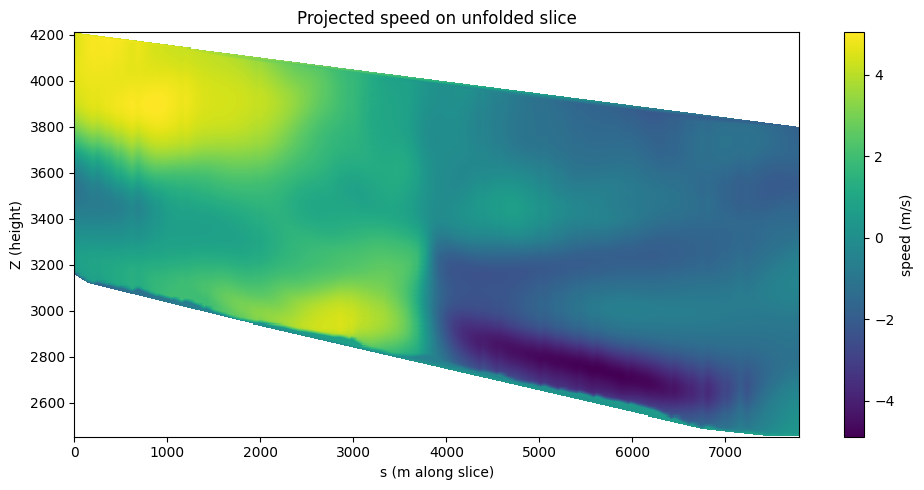

In [10]:
Zm = ma.masked_invalid(grid_v_rad)
ds = s_grid[1] - s_grid[0]
dz = z_grid[1] - z_grid[0]
s_edges = np.concatenate([[s_grid[0]-ds/2], s_grid + ds/2])
z_edges = np.concatenate([[z_grid[0]-dz/2], z_grid + dz/2])

plt.figure(figsize=(10,5))
pcm = plt.pcolormesh(s_edges, z_edges, Zm, shading='auto')
plt.xlabel('s (m along slice)'); plt.ylabel('Z (height)')
plt.title('Projected speed on unfolded slice')
plt.colorbar(pcm, label='speed (m/s)')
plt.tight_layout()
plt.show()